# 4.10

(a)

From eq 4.5.3

$$ \Delta f = 2f_0 \sqrt{\frac{2K_B T ln(2)}{M c^2}}$$


Where M is the mass of the lasing atom or molecule

In [52]:
from scipy.constants import c, k
import numpy as np

T = 130 + 273.15 # Degrees kelvin
lam0 = 632.8e-9
L=40e-2
M = 3.35e-26

f0 = c/lam0
delta_nu = 2*f0*np.sqrt((2*k*T*np.log(2))/(M*c**2))
delta_lam = delta_nu*np.abs(-lam0/f0)

print(f"∆nu = {delta_nu}")
print(f"∆lam = {delta_lam}")

∆nu = 1516854147.6191628
∆lam = 2.0260775364781306e-12


(b through c)

Each mode in the cavity satisfies $m(\lambda/2) = L

In [53]:
m0 = round(2*L/lam0)

m0 # Central mode number

1264223

recall, the separation between two resonant modes is 
$$ \Delta \lambda_m \approx \frac{\lambda_0^2}{2L}$$

and 

$$ \Delta \nu_m = \frac{c}{2L} $$

In [54]:
delta_lam_m = lam0**2 / (2*L)
delta_nu_m = c / (2*L)

num_modes = delta_lam / delta_lam_m

print(f"Given the separation of modes in wavelength is {delta_lam_m}")
print(f"And separation in frequency is {delta_nu_m}")
print(f"We expect that the number of modes that satisfy our conditions is approximately {num_modes}")

Given the separation of modes in wavelength is 5.005447999999999e-13
And separation in frequency is 374740572.5
We expect that the number of modes that satisfy our conditions is approximately 4.0477446503852015


Thus, we expect between 4 and 5 modes in the cavity

Let us solve for the exact mode numbers. We have already found that the mode number of the central mode is 1264223 (which we rounded up to the nearest integer)

If instead, we only allow valid modes between lam_min = lam0 - 0.5delta_lam and lam_max = lam0 + 0.5delta_lam, then we can check in this range for integer solutions m

In [55]:
import math

@np.vectorize
def round_up(x):
    return math.ceil(x)

def find_mode_numbers(lam0, delta_lam, L):
    lam_min = lam0 - delta_lam/2
    lam_max = lam0 + delta_lam/2

    
    lam = np.linspace(lam_min, lam_max, 1000)
    
    mode_numbers = list(set(round_up(2*L/lam)))
    mode_numbers.sort()
    
    mode_numbers = [int(m) for m in mode_numbers ]


    mode_numbers_to_remove = []
    # Make sure that min and max in range
    for m in [max(mode_numbers), min(mode_numbers)]:
        lam = 2*L/m
        if not (lam_min < lam) or not (lam < lam_max):
            mode_numbers_to_remove.append(m)
    for m in mode_numbers_to_remove:
        mode_numbers.remove(m)

    return mode_numbers

mode_numbers = find_mode_numbers(lam0, delta_lam, L)

print(f"The mode numbers that satisfy our conditions are: {mode_numbers}")

The mode numbers that satisfy our conditions are: [1264221, 1264222, 1264223, 1264224]


(d)

Beginning with the cavity condition:  
$$ m(\lambda_m/2) = L $$
where m is an integer. Solving for  $\lambda$  
$$ \lambda_m = 2L/m $$

If the length changes by $\delta L$, we will have a new resonant wavelength with   
$$ \lambda_m' = 2(L + \delta L)/m $$
$$ \lambda_m' = 2L/m + 2\delta L/m $$
$$ \lambda_m' = \lambda_m + 2\delta L/m $$
$$ \lambda_m' = \lambda_m + \delta \lambda_m $$

Where, 
$$\delta \lambda_m = 2\delta L/m = (2/m)\delta L$$

Now, we can solve for $2/m$  
$$ \lambda_m = 2L/m $$
$$ 2/m = \lambda_m / L $$

Substituting we have:  
$$ \delta \lambda_m =(\lambda_m / L)\delta L $$

(e)

1293467260.5914347
1516854147.6191628
1.7276973959345904e-12
2.0260775364781306e-12


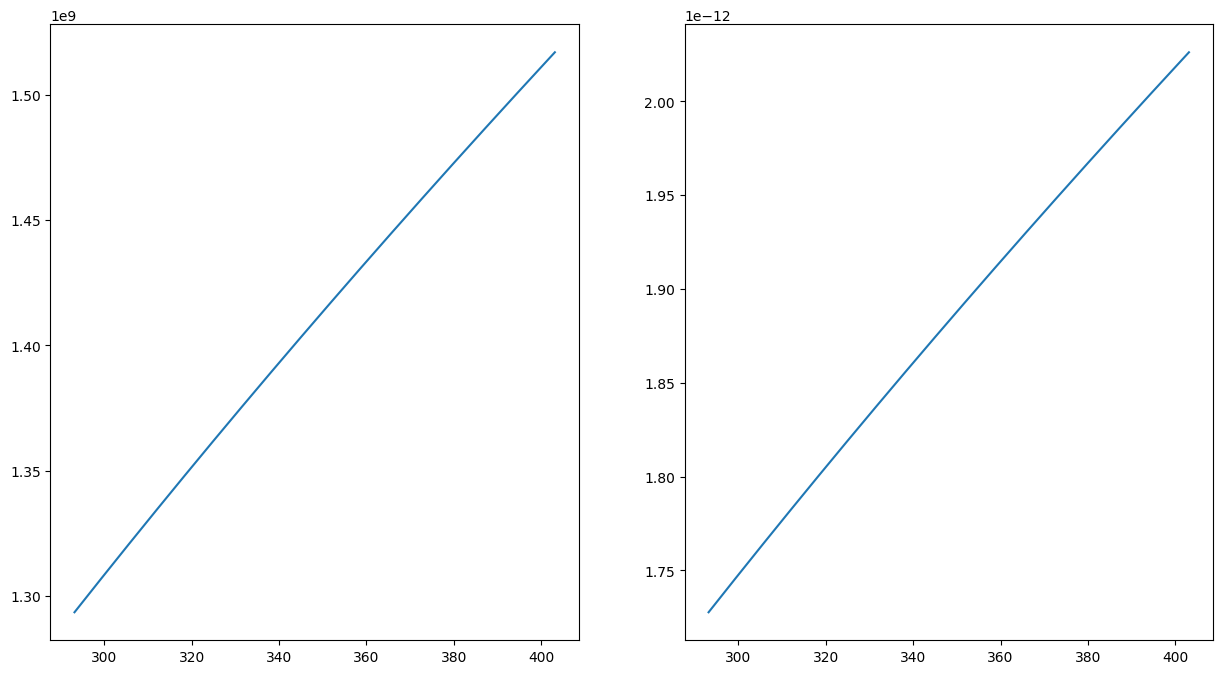

In [56]:
import matplotlib.pyplot as plt

T = np.linspace(20, 130, 1000) + 273.15
delta_nu = 2*f0*np.sqrt((2*k*T*np.log(2))/(M*c**2))
delta_lam = delta_nu*np.abs(-lam0/f0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
ax1.plot(T, delta_nu)
ax2.plot(T, delta_lam)

print(np.min(delta_nu))
print(np.max(delta_nu))
print(np.min(delta_lam))
print(np.max(delta_lam))

Clearly delta_nu and delta_lam monotonically increase over this range from delta_nu(T=20 degrees) = 1.29 GHz to delta_nu(T=130 degrees) = 1.51 GHz

delta_lam(T=20 degrees) = 1.73 pm to delta_nu(T=130 degrees) = 2.02 pm

(f)
One way that we can increase the output intensity is by adjusting the length of the cavity so that it is an integer multiple of lambda0/2, this would ensure that the light emitted at lambda0 is minimally attenuated by the spectral shape. 

Additionally, simply increasing the linewidth of the laser (by increasing temperature) would make the intensity less sensitive to the cavity length

# 4.12

![](eq4p2p7.png)

![](eq4p2p8.png)

In order to achieve more stimulated emission than spontaneous, R(stim) / R(spon) must be greater than 1  
$$ \frac{B_{21}\rho(\nu)}{A_{21}} > 1 $$

This begins when 
$$ \frac{B_{21}\rho(\nu)}{A_{21}} = 1 $$
$$ \rho(\nu) = \frac{A_{21}}{B_{21}} $$
$$ \rho(\nu) = \frac{8\pi h \nu^3}{c^3} = \frac{(N_{ph} h \nu)}{\Delta \nu}$$

$$ \rho(\nu) = \frac{8\pi h \nu^3}{c^3} = \frac{(N_{ph} h \nu)}{\Delta \nu}$$

$$ N_{ph} = \frac{\Delta \nu}{h \nu} \rho(\nu) $$

In [71]:
from scipy.constants import h, c

delta_nu = 5e9
lam = 488e-9
nu = c/lam

rho = 8*np.pi*h*nu**3 / c**3 

N_ph = delta_nu / (h*nu) *rho

print(f"{N_ph:e} photons per m^3")

1.760149e+15 photons per m^3


# 4.23

![](photon_cavity_lifetime.png)

$$ \tau_{ph} = n / (c \alpha_t) = n / (c(\alpha_s + \frac{1}{2L}ln(\frac{1}{R_1R_2})))$$
$$ \tau_{ph} = \frac{n/c}{\alpha_s} + \frac{n/c(2L)}{ln(\frac{1}{R_1R_2})}$$

Thus, if $R_1 = R_2 = 1$, the photon lifetime skyrockets to infinity, so we must consider non-unity reflectance products $R_1 R_2$ 

In [ ]:
alpha_s = 20e2 # 20 per cm
L=300e-6
n=3.78

print("If R_1, R_2 != 1, then: ")
print(f"tau_ph = {((n/c)/alpha_s):e} + {((n/c)*(2*L)):e}/ln(1/(R1*R2))")

If R_1 = R_2 = 1, then: 
tau_ph = 6.304361399245073e-12

If R_1, R_2 != 1, then: 
tau_ph = 6.304361e-12 + 7.565234e-12/ln(1/(R1*R2))


Text(0, 0.5, '$\\tau_{ph}$')

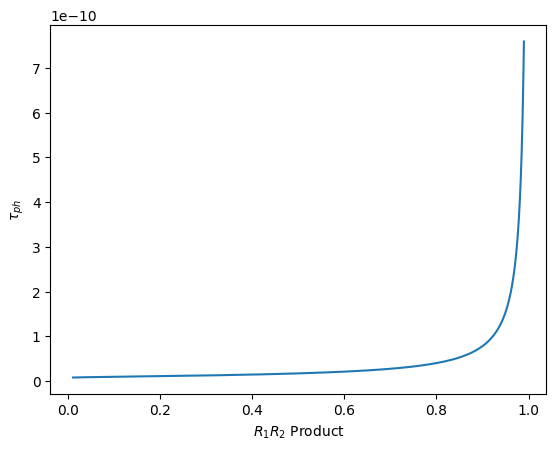

In [86]:
R1R2 = np.linspace(0.01, 0.99, 1000)

tau_ph = (n/c)/alpha_s + (n/c) * 2*L/(np.log(1/(R1R2)))

plt.plot(R1R2, tau_ph)
plt.xlabel(r"$R_1 R_2$ Product")
plt.ylabel(r"$\tau_{ph}$")

# 4.24

![](fig4p32.png)

6.1 Calculate the threshold small signal gain coefficient for ruby given the following data: threshold population inversion $5 \times 10^{22}$ $m^{-3}$, refractive index 1.5, linewidth $2 \times 10^{11}$ Hz, Einstein A coefficient 300 $s^{-1}$ and wavelength 694.3 nm.

![](pop_inv_wilson_and_hawkes.png)

For our case, let $g_2 = g_1$
$$ k = (N_2 - N_1) \frac{B_{21} h n }{\lambda_0 \Delta f}    $$
$$ k = (N_2 - N_1) \frac{B_{21} h n f}{c \Delta f}    $$



According to Planck's Law (Also, see page 298 in textbook)
$$ \frac{A_{21}}{B_{21}} = \frac{8\pi h \nu^3 n^3}{c^3} $$

$$ B_{21} = \frac{A_{21}c^3}{8\pi h \nu^3 n^3} $$

$$ k = (N_2 - N_1) \frac{A_{21}c^3 h n f}{8\pi h \nu^3 n^3 c \Delta f}    $$
$$ k = (N_2 - N_1) \frac{A_{21}c^2}{8\pi \nu^2 n^2 \Delta f}    $$

In [57]:
from scipy.constants import c
import numpy as np

population_inversion = 5e22 # per meter^3
n=1.5
A_21 = 300 # per second
delta_f = 2e11

f = c / (694.3e-9)

k = population_inversion*A_21*c**2 / (8*np.pi*(f**2)*(n**2)*delta_f)

print(f"small signal gain coefficient: k = {k}")

small signal gain coefficient: k = 0.6393419717771369


6.2 Calculate the threshold pumping power for an Nd:glass laser, given that the critical population inversion is $9 \times 10^{21}$ $m^{-3}$, the spontaneous lifetime is 300 μs and that the upper laser level is at an energy of 1.4 eV. 

![](ex4p2p1.png)

The above equation is obviously for a 3 state laser, while Nd:glass lasers are technically 4 state lasers

In [58]:
from scipy.constants import h
N_0 = 9e21 # per meter^3
tau_sp = 300e-6
E = 1.4 * 1.6021766339999e-19
f = E / h

min_power_per_unit_volume = (N_0 / 2)*h*f/tau_sp
print(f"P_pmin/V = {min_power_per_unit_volume / (100**3)} W/cm^3")

P_pmin/V = 3.36457093139979 W/cm^3


6.3 Estimate the efficiency of a GaAs laser operating well above threshold, given that n=3.6 and that the length of the laser cavity is 200 μm. Take the loss coefficient to be 800 m-1 and the internal quantum efficiency to be 0.8.

![](pce.png)
![](eqe.png)
![](iqe.png)